In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import seaborn as sns
from sklearn.metrics import confusion_matrix,accuracy_score
import numpy as np
from sklearn.metrics import roc_curve, auc


In [29]:
DATA_ROOT = "data/Scores/"

eval_df = pd.read_csv(DATA_ROOT + "All_CV_scores_evals.csv")

In [30]:
eval_df

,Sample Name,Score,Score_semi_sup_CV,Split,TS,Score_unsup_CV
0,906 - 2,7,6.745817,Train,906,6.391877
1,902 - 2,6,6.052775,Train,902,6.819692
2,904 - 6,5,5.751569,Train,904,7.121300
3,905 h1,9,8.050047,Train,905,8.583879
4,901 - 6,6,6.052775,Train,901,7.038324
...,...,...,...,...,...,...
76,903 h2,7,6.714761,Test,903,8.551630
77,906 - 6,5,6.648268,Test,906,6.373573
78,902 h2,8,6.991229,Test,902,8.634130
79,903 - 2,5,5.525752,Test,903,6.990453


In [31]:
eval_df['texture'] = eval_df['Score'].apply(lambda x: 0 if int(x) > 5 else 1)
eval_df['texture_type'] = eval_df['Score'].apply(lambda x: 'Fibrous' if int(x) > 5 else 'Porous')

eval_df['texture_unsup_CV'] = eval_df['Score_unsup_CV'].apply(lambda x: 0 if int(x) > 5 else 1)
eval_df['texture_type_unsup_CV'] = eval_df['Score_unsup_CV'].apply(lambda x: 'Fibrous' if int(x) > 5 else 'Porous')

eval_df['texture_semi_sup_CV'] = eval_df['Score_semi_sup_CV'].apply(lambda x: 0 if int(x) > 5 else 1)
eval_df['texture_type_semi_sup_CV'] = eval_df['Score_semi_sup_CV'].apply(lambda x: 'Fibrous' if int(x) > 5 else 'Porous')

In [32]:
test_samples = eval_df[eval_df['Split'] =='Test']
unsup_cv_accuracy = (test_samples['texture_unsup_CV'] == test_samples['texture']).mean()
unsup_cv_mae = mean_absolute_error(test_samples['Score'], test_samples['Score_unsup_CV'])

print(f"Unsupervised CV Test Accuracy: {unsup_cv_accuracy:.2f}")
print(f"CV Method MAE: {unsup_cv_mae:.2f}")

semi_sup_cv_accuracy = (test_samples['texture_semi_sup_CV'] == test_samples['texture']).mean()
print(f"Semi-Supervised CV Test Accuracy: {semi_sup_cv_accuracy:.2f}")

semi_sup_cv_mae = mean_absolute_error(test_samples['Score'], test_samples['Score_semi_sup_CV'])
print(f"Semi-Supervised CV Method MAE: {semi_sup_cv_mae:.2f}")


unsup_cv_bias = (test_samples['Score_unsup_CV'] - test_samples['Score']).mean()
semi_sup_bias = (test_samples['Score_semi_sup_CV'] - test_samples['Score']).mean()

print(f"\nMean Bias (predicted - true):")
print(f"CV Method Bias: {unsup_cv_bias:.2f}")
print(f"Semi-Supervised CV Method Bias: {semi_sup_bias:.2f}")


Unsupervised CV Test Accuracy: 0.76
CV Method MAE: 1.51
Semi-Supervised CV Test Accuracy: 0.84
Semi-Supervised CV Method MAE: 1.09

Mean Bias (predicted - true):
CV Method Bias: 1.16
Semi-Supervised CV Method Bias: -0.05


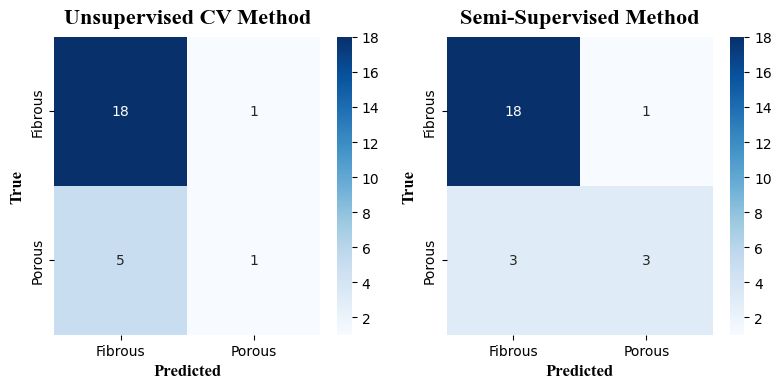

In [33]:

test_samples = eval_df[eval_df['Split'] == 'Test']

cm_cv = confusion_matrix(test_samples['texture_type'], test_samples['texture_type_unsup_CV'])
cm_rf = confusion_matrix(test_samples['texture_type'], test_samples['texture_type_semi_sup_CV'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Fibrous','Porous'],
            yticklabels=['Fibrous','Porous'])
ax1.set_xlabel('Predicted', fontsize=12, weight='bold', fontname='Times New Roman')
ax1.set_ylabel('True', fontsize=12, weight='bold', fontname='Times New Roman')
ax1.set_title('Unsupervised CV Method', fontsize=16, weight='bold', fontname='Times New Roman', pad=10)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Fibrous','Porous'],
            yticklabels=['Fibrous','Porous'])
ax2.set_xlabel('Predicted', fontsize=12, weight='bold', fontname='Times New Roman')
ax2.set_ylabel('True', fontsize=12, weight='bold', fontname='Times New Roman')
ax2.set_title('Semi-Supervised Method', fontsize=16, weight='bold', fontname='Times New Roman', pad=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


C:\Users\amirbg\AppData\Local\Temp\ipykernel_10116\995116551.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontweight='bold', fontname='Times New Roman')
C:\Users\amirbg\AppData\Local\Temp\ipykernel_10116\995116551.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(plt.gca().get_yticklabels(), fontweight='bold', fontname='Times New Roman')


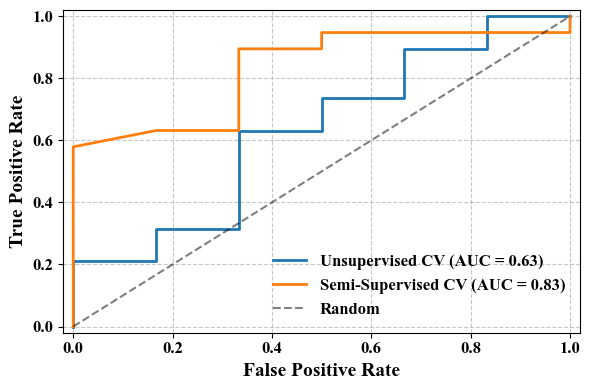

Area Under Curve (AUC):
CV Method:       0.632
RF Gabor Method: 0.829


In [34]:

y_true = (test_samples['texture_type'] == 'Fibrous').astype(int).values




fpr_cv, tpr_cv, _ = roc_curve(y_true, test_samples['Score_unsup_CV'])
fpr_rf, tpr_rf, _ = roc_curve(y_true, test_samples['Score_semi_sup_CV'])


auc_cv = auc(fpr_cv, tpr_cv)
auc_rf = auc(fpr_rf, tpr_rf)


plt.figure(figsize=(6, 4))
plt.plot(fpr_cv, tpr_cv, color='#1f77b4', linewidth=2, label=f'Unsupervised CV (AUC = {auc_cv:.2f})')
plt.plot(fpr_rf, tpr_rf, color='#ff7f0e', linewidth=2, label=f'Semi-Supervised CV (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')  

plt.xlabel('False Positive Rate', fontsize=14, weight='bold', fontname='Times New Roman')
plt.ylabel('True Positive Rate', fontsize=14, weight='bold', fontname='Times New Roman')

plt.legend(fontsize=16, frameon=False, prop={'weight':'bold', 'family':'Times New Roman','size':12})
plt.grid(True, linestyle='--', alpha=0.7)

plt.tick_params(axis='both', which='major', labelsize=12)
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontweight='bold', fontname='Times New Roman')
plt.gca().set_yticklabels(plt.gca().get_yticklabels(), fontweight='bold', fontname='Times New Roman')
plt.tight_layout()


plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Area Under Curve (AUC):")
print(f"CV Method:       {auc_cv:.3f}")
print(f"RF Gabor Method: {auc_rf:.3f}")
